# 🔬 EDA para NLP & RAG — Boletín Oficial de Salta
**Corpus:** Edición N° 21.922 — Salta, 31 de marzo de 2025  
**Pipeline:** Ingesta PDF → EDA → Wrangling → Chunking & Metadata

---

## Estrategia de segmentación: patrón `OP N°`

Cada documento del Boletín Oficial termina con un código de Orden de Publicación:

```
┌────────────────────────────────────────────────────┐
│  [Cabecera de página — boilerplate repetido]       │
├────────────────────────────────────────────────────┤
│                                                    │
│  DECRETO Nº 168                                    │
│  MINISTERIO DE SEGURIDAD Y JUSTICIA                │
│  ...cuerpo del documento...                        │
│                                                    │
│  SÁENZ - Solá Usandivaras - López Morillo          │
│  Fechas de publicación: 31/03/2025                 │
│  OP N°: SA100050312   ◄── DELIMITADOR CONFIABLE   │
├────────────────────────────────────────────────────┤
│  [Siguiente documento...]                          │
└────────────────────────────────────────────────────┘
```

**Ventaja sobre el enfoque anterior:** el patrón `OP N°: SA1000XXXXX` es:
- **Único** por documento (no se repite en el cuerpo)
- **Robusto** ante nombres de leyes/decretos con formato variable
- **Agnóstico al tipo** de documento (funciona para LEY, DECRETO, DECISIÓN ADMINISTRATIVA)
- El número OP es además **metadata valiosa** para el índice vectorial

```
FASE 0: Ingesta PDF    → pdfplumber + segmentación por OP
FASE 1: EDA            → Análisis exploratorio del corpus
FASE 2: Wrangling      → Limpieza y normalización
FASE 3: Chunking       → Segmentación semántica + metadatos
```

## ⚙️ Instalación y Setup

In [ ]:
!pip install tiktoken pdfplumber pypdf langdetect nltk matplotlib seaborn scikit-learn -q
import warnings; warnings.filterwarnings('ignore')
print('✅ OK')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 43.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 91.0 MB/s eta 0:00:00
✅ OK


In [ ]:
import re, json, hashlib, unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import pdfplumber
import tiktoken
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

enc = tiktoken.get_encoding('cl100k_base')
stop_es = set(stopwords.words('spanish'))

TIPO_COLORS = {
    'LEY':                     '#e74c3c',
    'DECRETO':                 '#3498db',
    'DECISION_ADMINISTRATIVA': '#2ecc71'
}
print('✅ Imports OK')

✅ Imports OK


---
# 📄 FASE 0: Ingesta del PDF

### 0.1 Extracción de texto por página

In [ ]:
# ─── CONFIGURACIÓN ───────────────────────────────────────
PDF_PATH = '/content/02c_ejemplo_boletin.pdf'    # ← ajustar ruta

# Cabecera repetida en cada página del boletín
HEADER_RE = re.compile(
    r'Edici[oó]n\s+N[°º]\s*[\d\.]+\s*\n'
    r'Salta,\s+[^\n]+\n'
    r'Decreto\s+Reglamentario[^\n]+\n',
    re.IGNORECASE
)

def extraer_corpus(pdf_path: str) -> tuple:
    """
    Extrae texto del PDF página a página.
    Retorna (pages_info, corpus_completo).
    """
    pages_info, corpus = [], ''

    with pdfplumber.open(pdf_path) as pdf:
        print(f'📖 {pdf_path}  |  {len(pdf.pages)} páginas')
        for i, page in enumerate(pdf.pages):
            raw   = page.extract_text() or ''
            clean = HEADER_RE.sub('', raw)
            pages_info.append({
                'pagina':           i + 1,
                'chars_raw':        len(raw),
                'chars_clean':      len(clean),
                'header_eliminado': len(raw) - len(clean),
            })
            corpus += clean + '\n'
            print(f'  Pág {i+1:2d}: {len(raw):5d} → {len(clean):5d} chars  '
                  f'(−{len(raw)-len(clean)} header)')

    return pages_info, corpus


pages_info, CORPUS = extraer_corpus(PDF_PATH)
df_pages = pd.DataFrame(pages_info)
print(f'\n✅ Corpus: {len(CORPUS):,} chars totales')

📖 /content/02c_ejemplo_boletin.pdf  |  13 páginas
  Pág  1:  2302 →  2202 chars  (−100 header)
  Pág  2:  1822 →  1722 chars  (−100 header)
  Pág  3:  3685 →  3585 chars  (−100 header)
  Pág  4:  2570 →  2470 chars  (−100 header)
  Pág  5:  2618 →  2518 chars  (−100 header)
  Pág  6:  2993 →  2893 chars  (−100 header)
  Pág  7:  3527 →  3427 chars  (−100 header)
  Pág  8:  2753 →  2653 chars  (−100 header)
  Pág  9:  2932 →  2832 chars  (−100 header)
  Pág 10:  2987 →  2887 chars  (−100 header)
  Pág 11:  2940 →  2840 chars  (−100 header)
  Pág 12:  2354 →  2254 chars  (−100 header)
  Pág 13:  2089 →  1989 chars  (−100 header)

✅ Corpus: 34,285 chars totales


### 0.2 Segmentación por patrón `OP N°` — delimitador confiable

Cada documento del boletín termina con `OP N°: SA1000XXXXX`.
Usamos ese patrón como **marcador de fin de documento** para segmentar el corpus.

In [ ]:
# ── Patrón OP: marcador de FIN de cada documento ──────────────────────────
PATRON_OP = re.compile(r'OP\s*N[°º]:\s*[A-Z]*\d{6,}', re.IGNORECASE)

# ── Patrones auxiliares para parsear el tipo dentro de cada segmento ──────
PATRON_TIPO = re.compile(
    r'(?P<tipo>DECISI[ÓO]N\s+ADMINISTRATIVA|DECRETO|LEY)\s+N[°º]\s*(?P<numero>\d+)',
    re.IGNORECASE
)

def segmentar_por_op(corpus: str) -> list:
    """
    Divide el corpus en documentos individuales usando el patrón OP como
    marcador de fin. Cada segmento va desde el fin del OP anterior hasta
    el fin del OP actual (inclusive).

    Retorna lista de dicts con:
      id, tipo, numero, op_numero, op_codigo, texto, posicion_inicio, posicion_fin
    """
    op_matches = list(PATRON_OP.finditer(corpus))
    print(f'🔍 OPs detectados: {len(op_matches)}')
    print()

    documentos = []
    prev_end   = 0

    for i, op_match in enumerate(op_matches):
        # Segmento: desde fin del OP anterior hasta fin de este OP
        bloque = corpus[prev_end : op_match.end()].strip()
        op_cod  = op_match.group().strip()
        op_num  = re.search(r'\d{6,}', op_cod).group()

        # Detectar tipo y número del documento dentro del bloque
        tipo_match = PATRON_TIPO.search(bloque)
        if tipo_match:
            tipo_raw = tipo_match.group('tipo').upper()
            numero   = tipo_match.group('numero')
            tipo = ('DECISION_ADMINISTRATIVA'
                    if 'DECISI' in tipo_raw.replace('Ó','O').replace('ó','o')
                    else tipo_raw)
        else:
            # Fallback si no hay tipo reconocible (p.ej. fragmento de página)
            tipo, numero = 'DESCONOCIDO', str(i + 1)

        doc_id = f'{tipo}_{numero}'

        print(f'  [{i+1:2d}] OP {op_cod:25s}  →  {doc_id}')

        documentos.append({
            'id':              doc_id,
            'tipo':            tipo,
            'numero':          numero,
            'op_codigo':       op_cod,
            'op_numero':       op_num,
            'posicion_inicio': prev_end,
            'posicion_fin':    op_match.end(),
            'texto':           bloque,
        })

        prev_end = op_match.end()

    # Texto residual al final (sin OP → ignorar o marcar)
    residuo = corpus[prev_end:].strip()
    if len(residuo) > 50:
        print(f'\n  ⚠️  Texto residual sin OP: {len(residuo)} chars (no indexado)')

    return documentos


DOCUMENTOS_RAW = segmentar_por_op(CORPUS)
print(f'\n✅ {len(DOCUMENTOS_RAW)} documentos segmentados')

🔍 OPs detectados: 12

  [ 1] OP OP N°: SA100050325         →  LEY_8488
  [ 2] OP OP N°: SA100050311         →  DECRETO_167
  [ 3] OP OP N°: SA100050312         →  DECRETO_168
  [ 4] OP OP N°: SA100050313         →  DECRETO_169
  [ 5] OP OP N°: SA100050314         →  DECRETO_170
  [ 6] OP OP N°: SA100050315         →  DECRETO_171
  [ 7] OP OP N°: SA100050316         →  DECRETO_172
  [ 8] OP OP N°: SA100050317         →  DECRETO_173
  [ 9] OP OP N°: SA100050318         →  DECRETO_174
  [10] OP OP N°: SA100050326         →  DECRETO_188
  [11] OP OP N°: SA100050295         →  DECISION_ADMINISTRATIVA_110
  [12] OP OP N°: SA100050296         →  DECISION_ADMINISTRATIVA_111

✅ 12 documentos segmentados


### 0.3 Parser de metadatos por documento

In [ ]:
MESES_ES = {'enero':'01','febrero':'02','marzo':'03','abril':'04',
            'mayo':'05','junio':'06','julio':'07','agosto':'08',
            'septiembre':'09','octubre':'10','noviembre':'11','diciembre':'12'}

def fecha_iso(raw: str) -> str:
    try:
        p = raw.lower().split()
        return f'{p[4]}-{MESES_ES.get(p[2],"00")}-{p[0].zfill(2)}'
    except Exception:
        return raw

def parsear_metadatos(doc: dict) -> dict:
    t = doc['texto']

    # Fecha de firma
    m = re.search(r'SALTA,?\s+(\d{1,2}\s+de\s+\w+\s+de\s+\d{4})', t, re.I)
    fecha = fecha_iso(m.group(1)) if m else '2025-03-25'

    # Fecha de publicación (antes del OP)
    m2 = re.search(r'Fechas?\s+de\s+publicaci[oó]n:\s*([\d/]+)', t, re.I)
    fecha_pub = m2.group(1) if m2 else '31/03/2025'

    # Ministerio / organismo
    ministerio = 'Gobernación de Salta'
    for linea in [l.strip() for l in t.splitlines() if l.strip()][:12]:
        if re.search(r'MINISTERIO|SECRETAR[IÍ]A|LEGISLATURA|GOBERNACI[OÓ]N', linea, re.I):
            ministerio = linea; break

    # Expediente
    m3 = re.search(r'Expediente\s+N[°º]?\s*([\d\-/]+)', t, re.I)
    expediente = m3.group(1) if m3 else ''

    # Firmantes (última línea con guiones antes del OP)
    lineas = [l.strip() for l in t.splitlines() if l.strip()]
    firmantes = ''
    for linea in reversed(lineas[:-3]):  # excluir las 3 últimas (fecha pub + OP)
        if re.search(r'SÁENZ|SAENZ|Demitrópulos|Mashur', linea, re.I):
            firmantes = linea; break

    return {
        **doc,
        'fecha':       fecha,
        'fecha_pub':   fecha_pub,
        'ministerio':  ministerio,
        'expediente':  expediente,
        'firmantes':   firmantes,
        'num_chars':   len(t),
        'num_palabras':len(t.split()),
        'num_tokens':  len(enc.encode(t)),
    }


DOCUMENTOS = [parsear_metadatos(d) for d in DOCUMENTOS_RAW]
df = pd.DataFrame(DOCUMENTOS)

print('📋 Corpus estructurado (segmentado por OP N°):')
print()
print(df[['id','op_codigo','tipo','fecha','num_tokens']].to_string(index=False))

📋 Corpus estructurado (segmentado por OP N°):

                         id          op_codigo                    tipo      fecha  num_tokens
                   LEY_8488 OP N°: SA100050325                     LEY 2025-03-27         755
                DECRETO_167 OP N°: SA100050311                 DECRETO 2025-03-25         528
                DECRETO_168 OP N°: SA100050312                 DECRETO 2025-03-25        1248
                DECRETO_169 OP N°: SA100050313                 DECRETO 2025-03-25        1217
                DECRETO_170 OP N°: SA100050314                 DECRETO 2025-03-25        1231
                DECRETO_171 OP N°: SA100050315                 DECRETO 2025-03-25        1227
                DECRETO_172 OP N°: SA100050316                 DECRETO 2025-03-25        1222
                DECRETO_173 OP N°: SA100050317                 DECRETO 2025-03-25        1227
                DECRETO_174 OP N°: SA100050318                 DECRETO 2025-03-25         984
             

### 0.4 Dashboard de ingesta — mapa del corpus por OP

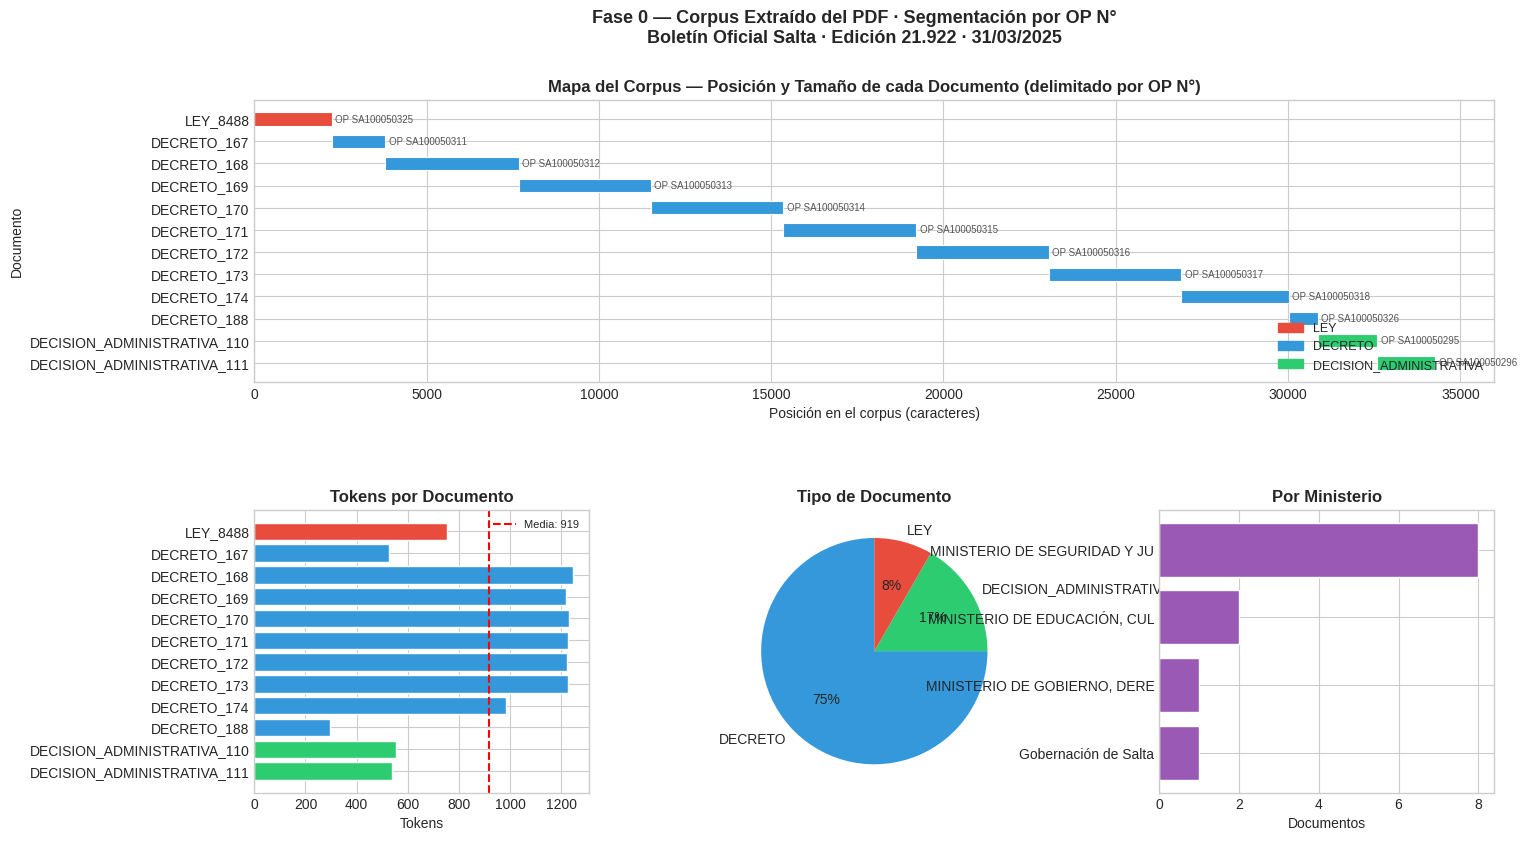

✅ Fase 0 completa
   Páginas:     13
   OPs / Docs:  12
   Tipos:       {'DECRETO': 9, 'DECISION_ADMINISTRATIVA': 2, 'LEY': 1}
   Tokens tot:  11,032


In [ ]:
fig = plt.figure(figsize=(16, 9))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

bar_colors = [TIPO_COLORS.get(t, '#95a5a6') for t in df['tipo']]

# ── Gráfico 1: Mapa de posición en el corpus por OP ──────────────────────
ax1 = fig.add_subplot(gs[0, :])
for _, row in df.iterrows():
    color = TIPO_COLORS.get(row['tipo'], '#95a5a6')
    ax1.barh(
        y      = row['id'],
        width  = row['posicion_fin'] - row['posicion_inicio'],
        left   = row['posicion_inicio'],
        color  = color,
        edgecolor = 'white',
        linewidth = 0.8,
        height = 0.6
    )
    # Anotar el OP code al final de cada barra
    ax1.text(
        x      = row['posicion_fin'] + 100,
        y      = row['id'],
        s      = row['op_codigo'].replace('OP N°: ','OP '),
        va     = 'center',
        fontsize = 7,
        color  = '#555555'
    )

ax1.set_title('Mapa del Corpus — Posición y Tamaño de cada Documento (delimitado por OP N°)',
              fontweight='bold', fontsize=12)
ax1.set_xlabel('Posición en el corpus (caracteres)')
ax1.set_ylabel('Documento')
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in TIPO_COLORS.items()]
ax1.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax1.invert_yaxis()

# ── Gráfico 2: Tokens por documento ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.barh(df['id'][::-1], df['num_tokens'][::-1], color=bar_colors[::-1], edgecolor='white')
ax2.axvline(df['num_tokens'].mean(), color='red', linestyle='--',
            label=f'Media: {df["num_tokens"].mean():.0f}')
ax2.set_title('Tokens por Documento', fontweight='bold')
ax2.set_xlabel('Tokens'); ax2.legend(fontsize=8)

# ── Gráfico 3: Distribución por tipo ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
tc  = df['tipo'].value_counts()
ax3.pie(tc, labels=tc.index, autopct='%1.0f%%',
        colors=[TIPO_COLORS[t] for t in tc.index], startangle=90)
ax3.set_title('Tipo de Documento', fontweight='bold')

# ── Gráfico 4: Distribución por ministerio ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
mc  = df['ministerio'].apply(lambda x: x[:28]).value_counts()
ax4.barh(mc.index[::-1], mc.values[::-1], color='#9b59b6', edgecolor='white')
ax4.set_title('Por Ministerio', fontweight='bold')
ax4.set_xlabel('Documentos')

plt.suptitle('Fase 0 — Corpus Extraído del PDF · Segmentación por OP N°\n'
             'Boletín Oficial Salta · Edición 21.922 · 31/03/2025',
             fontsize=13, fontweight='bold')
plt.show()

print(f'✅ Fase 0 completa')
print(f'   Páginas:     {len(pages_info)}')
print(f'   OPs / Docs:  {len(df)}')
print(f'   Tipos:       {df["tipo"].value_counts().to_dict()}')
print(f'   Tokens tot:  {df["num_tokens"].sum():,}')

---
# 📊 FASE 1: EDA — Análisis Exploratorio de Texto

> El `df` que alimenta esta fase fue construido automáticamente por la Fase 0,  
> con **12 documentos** delimitados por sus códigos `OP N°`.

### 1.1 Tokens vs. Caracteres — impacto del patrón OP en la medición

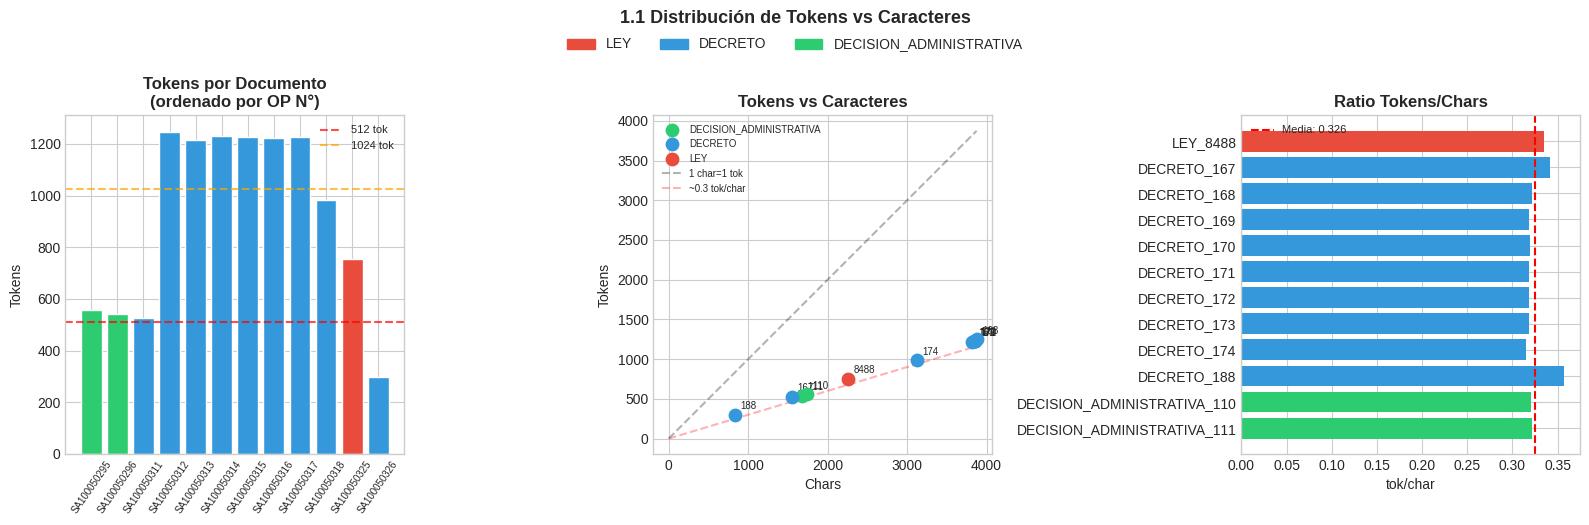

📌 Ratio promedio: 0.326 tok/char
   Chunk 250 tok ≈ 767 chars  |  Chunk 512 tok ≈ 1572 chars


In [ ]:
df['ratio_tc'] = df['num_tokens'] / df['num_chars']
bar_colors     = [TIPO_COLORS.get(t,'#95a5a6') for t in df['tipo']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tokens por documento, ordenados por OP
df_sorted = df.sort_values('op_numero')
axes[0].bar(df_sorted['op_codigo'].str.replace('OP N°: ','',regex=False),
            df_sorted['num_tokens'],
            color=[TIPO_COLORS.get(t,'#95a5a6') for t in df_sorted['tipo']],
            edgecolor='white')
axes[0].axhline(512,  color='red',    linestyle='--', alpha=0.7, label='512 tok')
axes[0].axhline(1024, color='orange', linestyle='--', alpha=0.7, label='1024 tok')
axes[0].set_title('Tokens por Documento\n(ordenado por OP N°)', fontweight='bold')
axes[0].set_ylabel('Tokens')
axes[0].tick_params(axis='x', rotation=55, labelsize=7)
axes[0].legend(fontsize=8)

# Scatter tokens vs chars
for tipo, grp in df.groupby('tipo'):
    axes[1].scatter(grp['num_chars'], grp['num_tokens'],
                    label=tipo, color=TIPO_COLORS[tipo], s=80, zorder=5)
    for _, r in grp.iterrows():
        axes[1].annotate(r['numero'], (r['num_chars'], r['num_tokens']),
                         xytext=(4,4), textcoords='offset points', fontsize=7)
mx = df['num_chars'].max()
axes[1].plot([0,mx],[0,mx],       'k--', alpha=0.3, label='1 char=1 tok')
axes[1].plot([0,mx],[0,mx*0.30],  'r--', alpha=0.3, label='~0.3 tok/char')
axes[1].set_title('Tokens vs Caracteres', fontweight='bold')
axes[1].set_xlabel('Chars'); axes[1].set_ylabel('Tokens'); axes[1].legend(fontsize=7)

# Ratio por documento
axes[2].barh(df['id'][::-1], df['ratio_tc'][::-1], color=bar_colors[::-1])
axes[2].axvline(df['ratio_tc'].mean(), color='red', linestyle='--',
                label=f'Media: {df["ratio_tc"].mean():.3f}')
axes[2].set_title('Ratio Tokens/Chars', fontweight='bold')
axes[2].set_xlabel('tok/char'); axes[2].legend(fontsize=8)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in TIPO_COLORS.items()]
fig.legend(handles=legend_patches, loc='upper center', ncol=3, bbox_to_anchor=(0.5,1.01))
plt.suptitle('1.1 Distribución de Tokens vs Caracteres', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

r = df['ratio_tc'].mean()
print(f'📌 Ratio promedio: {r:.3f} tok/char')
print(f'   Chunk 250 tok ≈ {int(250/r)} chars  |  Chunk 512 tok ≈ {int(512/r)} chars')

### 1.2 Densidad de Stop-words

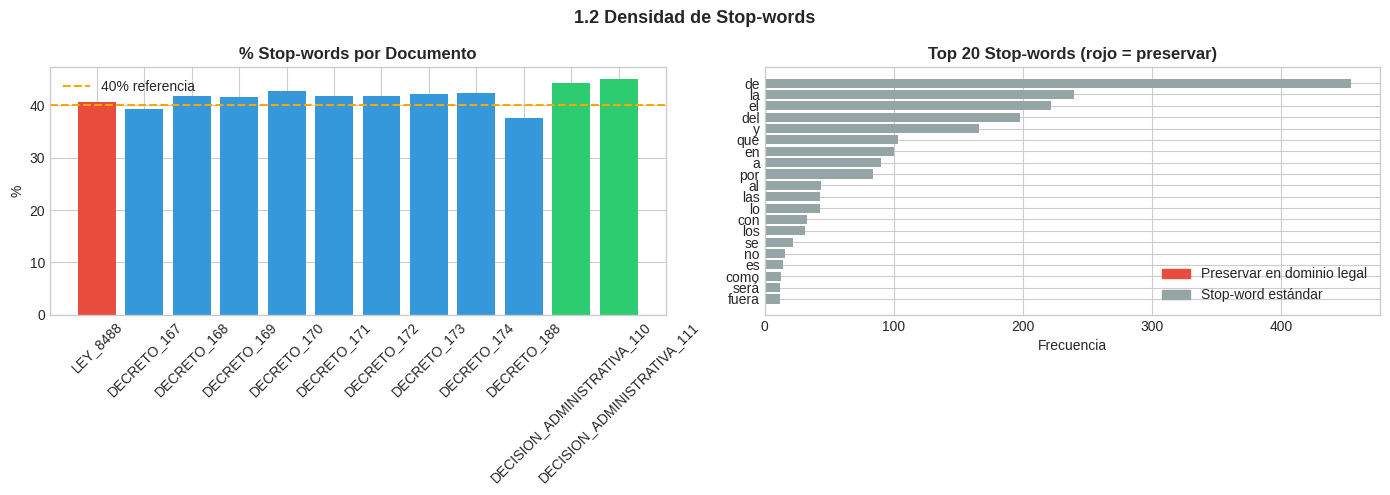

📌 Stop-words promedio: 41.8%


In [ ]:
PRESERVAR_EN_LEGAL = {'artículo','decreto','ley','resolución','ministerio',
                      'provincia','poder','ejecutivo','gobernador'}

def ratio_sw(texto):
    tok = [t for t in word_tokenize(texto.lower(), language='spanish') if t.isalpha()]
    sw  = [t for t in tok if t in stop_es]
    return len(sw) / max(len(tok), 1)

df['ratio_sw'] = df['texto'].apply(ratio_sw)

corpus_all  = ' '.join(df['texto'])
tokens_all  = [t for t in word_tokenize(corpus_all.lower(), language='spanish') if t.isalpha()]
sw_counter  = Counter(t for t in tokens_all if t in stop_es)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = [TIPO_COLORS.get(t,'#95a5a6') for t in df['tipo']]

axes[0].bar(df['id'], df['ratio_sw']*100, color=bar_colors)
axes[0].axhline(40, color='orange', linestyle='--', label='40% referencia')
axes[0].set_title('% Stop-words por Documento', fontweight='bold')
axes[0].set_ylabel('%'); axes[0].tick_params(axis='x', rotation=45); axes[0].legend()

top_sw = sw_counter.most_common(20)
sw_words, sw_counts = zip(*top_sw)
sw_cols = ['#e74c3c' if w in PRESERVAR_EN_LEGAL else '#95a5a6' for w in sw_words]
axes[1].barh(list(sw_words)[::-1], list(sw_counts)[::-1], color=list(sw_cols)[::-1])
axes[1].set_title('Top 20 Stop-words (rojo = preservar)', fontweight='bold')
axes[1].set_xlabel('Frecuencia')
axes[1].legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Preservar en dominio legal'),
    mpatches.Patch(color='#95a5a6', label='Stop-word estándar')
])

plt.suptitle('1.2 Densidad de Stop-words', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'📌 Stop-words promedio: {df["ratio_sw"].mean()*100:.1f}%')

### 1.3 N-Gramas de Dominio — Frases compuestas que no deben separarse

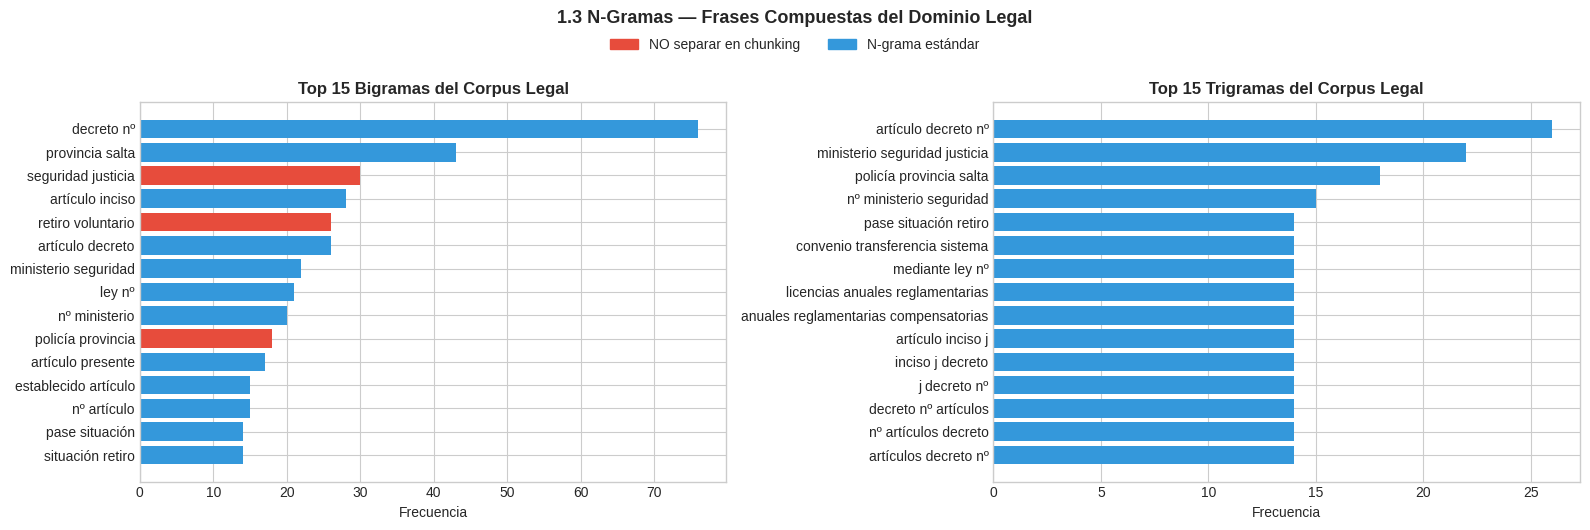

In [ ]:
def top_ngrams(texto, n, k=15):
    tok = [t for t in word_tokenize(texto.lower(), language='spanish')
           if t.isalpha() and t not in stop_es]
    return Counter(ngrams(tok, n)).most_common(k)

corpus_all_text = ' '.join(df['texto'])
bigrams_top     = top_ngrams(corpus_all_text, 2)
trigrams_top    = top_ngrams(corpus_all_text, 3)

NO_SEPARAR = ['retiro voluntario','boletín oficial','poder ejecutivo',
              'seguridad justicia','suboficial principal','suboficial mayor',
              'decreto reglamentario','cuerpo seguridad','escalafón general',
              'policía provincia']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, grams, titulo in [
    (axes[0], bigrams_top,  'Top 15 Bigramas'),
    (axes[1], trigrams_top, 'Top 15 Trigramas')
]:
    labels = [' '.join(g) for g,_ in grams]
    counts = [c for _,c in grams]
    clrs   = ['#e74c3c' if l in NO_SEPARAR else '#3498db' for l in labels]
    ax.barh(labels[::-1], counts[::-1], color=clrs[::-1])
    ax.set_title(titulo + ' del Corpus Legal', fontweight='bold')
    ax.set_xlabel('Frecuencia')

fig.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='NO separar en chunking'),
    mpatches.Patch(color='#3498db', label='N-grama estándar')
], loc='upper center', ncol=2, bbox_to_anchor=(0.5,1.02))
plt.suptitle('1.3 N-Gramas — Frases Compuestas del Dominio Legal',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

### 1.4 Boilerplate y Similitud — ¿Qué documentos son cuasi-idénticos?

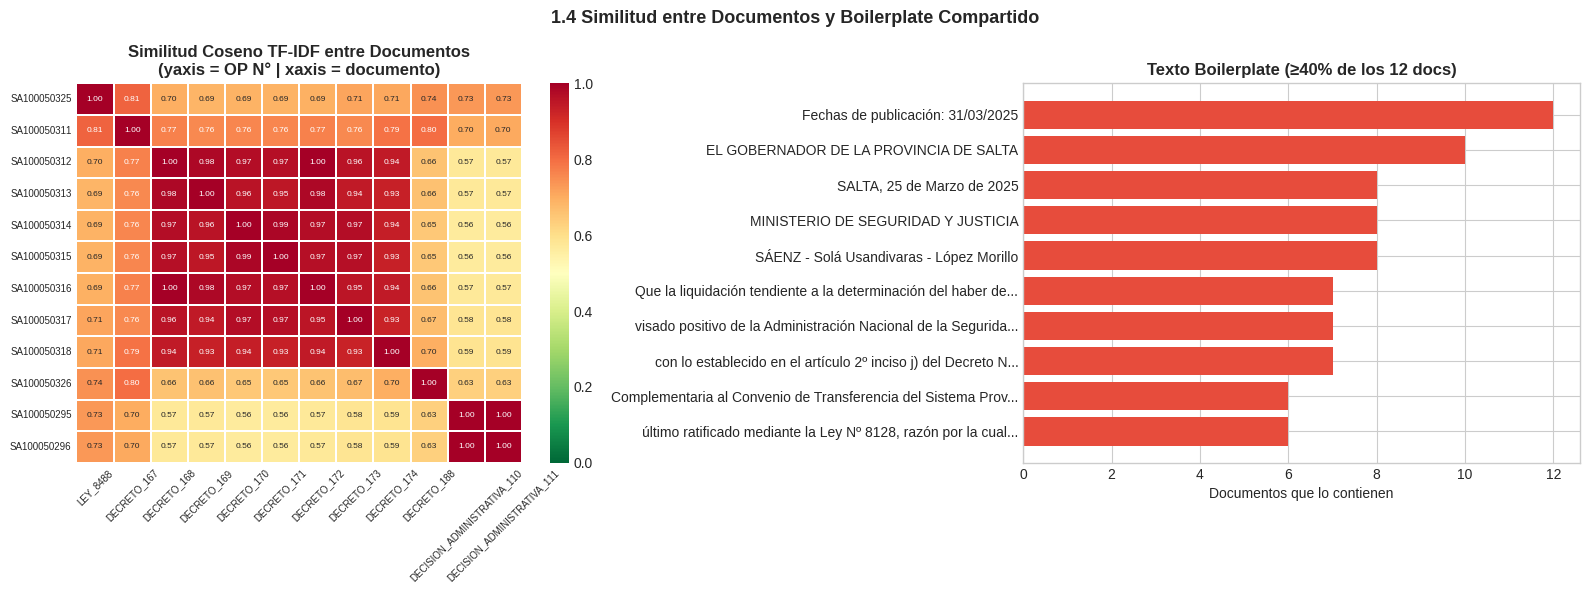

📌 Frases boilerplate detectadas: 29

⚠️  Pares con similitud > 0.50 (mismo template estructural):
   LEY_8488             ↔  DECRETO_167           sim=0.81
   LEY_8488             ↔  DECRETO_168           sim=0.70
   LEY_8488             ↔  DECRETO_169           sim=0.69
   LEY_8488             ↔  DECRETO_170           sim=0.69
   LEY_8488             ↔  DECRETO_171           sim=0.69
   LEY_8488             ↔  DECRETO_172           sim=0.69
   LEY_8488             ↔  DECRETO_173           sim=0.71
   LEY_8488             ↔  DECRETO_174           sim=0.71
   LEY_8488             ↔  DECRETO_188           sim=0.74
   LEY_8488             ↔  DECISION_ADMINISTRATIVA_110  sim=0.73
   LEY_8488             ↔  DECISION_ADMINISTRATIVA_111  sim=0.73
   DECRETO_167          ↔  DECRETO_168           sim=0.77
   DECRETO_167          ↔  DECRETO_169           sim=0.76
   DECRETO_167          ↔  DECRETO_170           sim=0.76
   DECRETO_167          ↔  DECRETO_171           sim=0.76
   DECRETO_167    

In [ ]:
tfidf_mat  = TfidfVectorizer(max_features=600, ngram_range=(1,2)).fit_transform(df['texto'])
sim_matrix = cosine_similarity(tfidf_mat)

def detectar_boilerplate(docs, umbral=0.4):
    lineas = [l.strip() for d in docs for l in d.split('\n') if len(l.strip()) > 25]
    return {l: c for l,c in Counter(lineas).items() if c/len(docs) >= umbral}

boilerplate = detectar_boilerplate(df['texto'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap de similitud con etiquetas de OP
op_labels = df['op_codigo'].str.replace('OP N°: ','',regex=False).tolist()
sns.heatmap(sim_matrix, annot=True, fmt='.2f',
            xticklabels=df['id'], yticklabels=op_labels,
            cmap='RdYlGn_r', ax=axes[0], vmin=0, vmax=1,
            annot_kws={'size':6}, linewidths=0.3)
axes[0].set_title('Similitud Coseno TF-IDF entre Documentos\n'
                  '(yaxis = OP N° | xaxis = documento)',
                  fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# Boilerplate
if boilerplate:
    sorted_bp = sorted(boilerplate.items(), key=lambda x: x[1], reverse=True)[:10]
    axes[1].barh(
        [l[:60]+'...' if len(l)>60 else l for l,_ in sorted_bp][::-1],
        [c for _,c in sorted_bp][::-1], color='#e74c3c')
    axes[1].set_title(f'Texto Boilerplate (≥40% de los {len(df)} docs)',
                      fontweight='bold')
    axes[1].set_xlabel('Documentos que lo contienen')
else:
    axes[1].text(0.5,0.5,'Sin boilerplate detectado\nal 40% de umbral',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)

plt.suptitle('1.4 Similitud entre Documentos y Boilerplate Compartido',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'📌 Frases boilerplate detectadas: {len(boilerplate)}')
print('\n⚠️  Pares con similitud > 0.50 (mismo template estructural):')
for i in range(len(df)):
    for j in range(i+1, len(df)):
        if sim_matrix[i,j] > 0.50:
            print(f'   {df["id"].iloc[i]:20s} ↔  {df["id"].iloc[j]:20s}  sim={sim_matrix[i,j]:.2f}')

### 1.5 Outliers de Longitud — Clasificación por umbrales de chunking

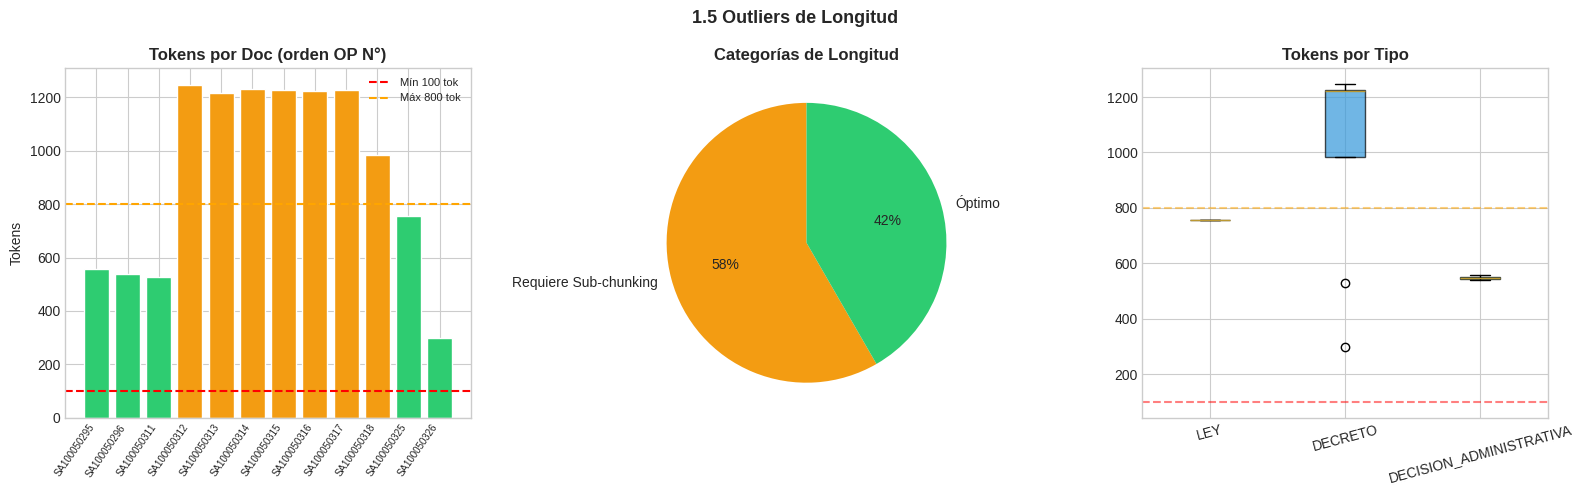

   🟢 OP N°: SA100050325      LEY_8488                    755 tok  Óptimo
   🟢 OP N°: SA100050311      DECRETO_167                 528 tok  Óptimo
   🟡 OP N°: SA100050312      DECRETO_168                1248 tok  Requiere Sub-chunking
   🟡 OP N°: SA100050313      DECRETO_169                1217 tok  Requiere Sub-chunking
   🟡 OP N°: SA100050314      DECRETO_170                1231 tok  Requiere Sub-chunking
   🟡 OP N°: SA100050315      DECRETO_171                1227 tok  Requiere Sub-chunking
   🟡 OP N°: SA100050316      DECRETO_172                1222 tok  Requiere Sub-chunking
   🟡 OP N°: SA100050317      DECRETO_173                1227 tok  Requiere Sub-chunking
   🟡 OP N°: SA100050318      DECRETO_174                 984 tok  Requiere Sub-chunking
   🟢 OP N°: SA100050326      DECRETO_188                 297 tok  Óptimo
   🟢 OP N°: SA100050295      DECISION_ADMINISTRATIVA_110   556 tok  Óptimo
   🟢 OP N°: SA100050296      DECISION_ADMINISTRATIVA_111   540 tok  Óptimo


In [ ]:
UMBRAL_CORTO, UMBRAL_LARGO = 100, 800
CAT_COLORS = {'Demasiado Corto':'#e74c3c','Óptimo':'#2ecc71','Requiere Sub-chunking':'#f39c12'}

df['cat'] = df['num_tokens'].apply(
    lambda t: 'Demasiado Corto' if t < UMBRAL_CORTO else
              'Requiere Sub-chunking' if t > UMBRAL_LARGO else 'Óptimo'
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = [TIPO_COLORS.get(t,'#95a5a6') for t in df['tipo']]

# Waterfall por OP order
df_s = df.sort_values('op_numero')
axes[0].bar(range(len(df_s)), df_s['num_tokens'],
            color=[CAT_COLORS[c] for c in df_s['cat']], edgecolor='white')
axes[0].axhline(UMBRAL_CORTO, color='red',    linestyle='--', label=f'Mín {UMBRAL_CORTO} tok')
axes[0].axhline(UMBRAL_LARGO, color='orange', linestyle='--', label=f'Máx {UMBRAL_LARGO} tok')
axes[0].set_xticks(range(len(df_s)))
axes[0].set_xticklabels(
    df_s['op_codigo'].str.replace('OP N°: ','',regex=False),
    rotation=55, ha='right', fontsize=7)
axes[0].set_title('Tokens por Doc (orden OP N°)', fontweight='bold')
axes[0].set_ylabel('Tokens'); axes[0].legend(fontsize=8)

cat_c = df['cat'].value_counts()
axes[1].pie(cat_c, labels=cat_c.index, autopct='%1.0f%%',
            colors=[CAT_COLORS[c] for c in cat_c.index], startangle=90)
axes[1].set_title('Categorías de Longitud', fontweight='bold')

tipos_u = df['tipo'].unique()
bp = axes[2].boxplot([df[df['tipo']==t]['num_tokens'].values for t in tipos_u],
                     labels=tipos_u, patch_artist=True)
for patch, tipo in zip(bp['boxes'], tipos_u):
    patch.set_facecolor(TIPO_COLORS[tipo]); patch.set_alpha(0.7)
axes[2].axhline(UMBRAL_CORTO, color='red',    linestyle='--', alpha=0.5)
axes[2].axhline(UMBRAL_LARGO, color='orange', linestyle='--', alpha=0.5)
axes[2].set_title('Tokens por Tipo', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('1.5 Outliers de Longitud', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

for _, row in df[['id','op_codigo','num_tokens','cat']].iterrows():
    e = {'Demasiado Corto':'🔴','Óptimo':'🟢','Requiere Sub-chunking':'🟡'}[row['cat']]
    print(f'   {e} {row["op_codigo"]:22s}  {row["id"]:25s}  {row["num_tokens"]:4d} tok  {row["cat"]}')

### 1.6 NER — Entidades para diseñar filtros de metadatos

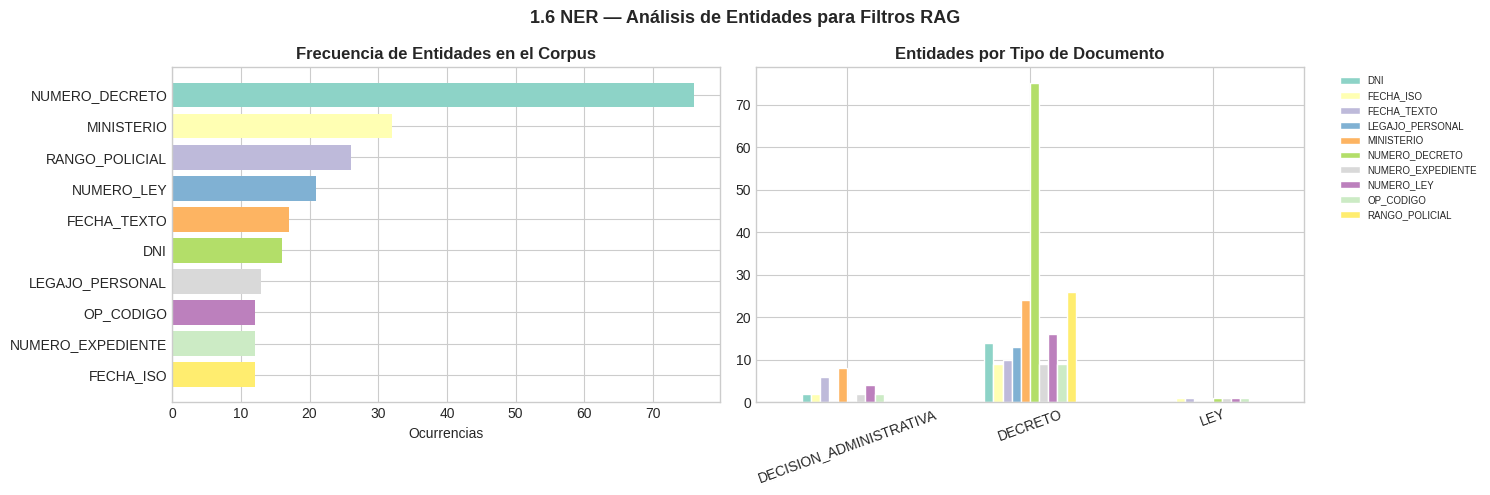

📌 Total entidades: 237
   OP_CODIGO detectados: 12 (debe coincidir con 12 docs)


In [ ]:
PATRONES_NER = {
    'NUMERO_LEY':        r'Ley\s+N[°º]\s*[\d\.]+',
    'NUMERO_DECRETO':    r'Decreto\s+N[°º]\s*[\d\.]+(?:/\d+)?',
    'NUMERO_EXPEDIENTE': r'Expediente\s+N[°º]?\s*[\d\-/]+',
    'DNI':               r'D\.?N\.?I\.?\s*N[°º]?\s*[\d\.]+',
    'FECHA_ISO':         r'\d{1,2}/\d{1,2}/\d{4}',
    'FECHA_TEXTO':       r'\d{1,2}\s+de\s+\w+\s+de\s+\d{4}',
    'MINISTERIO':        r'Ministerio\s+de\s+[\w\s,]+(?=\n|,|;|\.|$)',
    'RANGO_POLICIAL':    r'(?:Suboficial\s+(?:Principal|Mayor)|Sargento\s+(?:Ayudante|Primero))',
    'OP_CODIGO':         r'OP\s*N[°º]:\s*[A-Z]*\d{6,}',         # ← nuestro delimitador
    'LEGAJO_PERSONAL':   r'Legajo\s+Personal\s+N[°º]\s*[\d\.]+',
}

ner_rows = [
    {'doc_id': r['id'], 'op': r['op_codigo'], 'tipo_doc': r['tipo'],
     'tipo_entidad': te, 'valor': m.strip()[:60]}
    for _, r in df.iterrows()
    for te, pat in PATRONES_NER.items()
    for m in re.findall(pat, r['texto'], re.IGNORECASE)
]
df_ner = pd.DataFrame(ner_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

conteo = df_ner['tipo_entidad'].value_counts()
colors_ner = plt.cm.Set3(np.linspace(0, 1, len(conteo)))
axes[0].barh(conteo.index[::-1], conteo.values[::-1], color=colors_ner[::-1])
axes[0].set_title('Frecuencia de Entidades en el Corpus', fontweight='bold')
axes[0].set_xlabel('Ocurrencias')

pivot_ner = df_ner.groupby(['tipo_doc','tipo_entidad']).size().unstack(fill_value=0)
pivot_ner.plot(kind='bar', ax=axes[1], colormap='Set3', edgecolor='white')
axes[1].set_title('Entidades por Tipo de Documento', fontweight='bold')
axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=7, bbox_to_anchor=(1.05,1), loc='upper left')

plt.suptitle('1.6 NER — Análisis de Entidades para Filtros RAG',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'📌 Total entidades: {len(df_ner)}')
print(f'   OP_CODIGO detectados: {len(df_ner[df_ner["tipo_entidad"]=="OP_CODIGO"])} '
      f'(debe coincidir con {len(df)} docs)')

### 1.7 Lexical Richness — TTR

# 📈 Análisis de Riqueza Léxica: TTR y MATTR

Para entender la complejidad y variedad del vocabulario en nuestro corpus del **Boletín Oficial**, utilizamos dos métricas fundamentales de la lingüística computacional. Estas métricas nos ayudan a decidir si es necesario aplicar técnicas de normalización como la **lematización**.

### 1. Type-Token Ratio (TTR)
Es la relación básica entre el número de palabras únicas (**Types**) y el total de palabras de un texto (**Tokens**).

$$TTR = \frac{\text{Palabras únicas (Types)}}{\text{Total de palabras (Tokens)}}$$

*   **Interpretación:** Un valor de **1.0** indica que no hay repeticiones. Valores bajos sugieren un vocabulario limitado o alta redundancia.
*   **Limitación:** El TTR disminuye naturalmente a medida que el texto es más largo (Ley de Herdan), lo que hace injusta la comparación entre documentos de distintos tamaños.

### 2. Moving-Average Type-Token Ratio (MATTR)
Para corregir el sesgo por longitud, empleamos el **MATTR**. Esta métrica calcula el TTR de forma local mediante una **ventana deslizante** (en este análisis, de 50 tokens).

*   **Funcionamiento:** Se promedian los ratios de todas las ventanas posibles del documento.
*   **Ventaja:** Proporciona una medida de "densidad léxica" estable, permitiendo comparar un decreto corto con una ley extensa de manera objetiva.

---

### 💡 Justificación de la Lematización
El análisis de estos ratios es el paso previo a la **Lematización** (reducir palabras a su raíz: *decretos* → *decreto*).

*   **Si el TTR/MATTR es muy bajo:** Indica que el texto usa muchas variaciones de las mismas palabras. La lematización es **crítica** aquí para que el modelo de IA agrupe estos términos como un solo concepto y no como entidades distintas.
*   **Umbral Crítico:** Documentos con un TTR inferior a **0.4** suelen ser candidatos urgentes para un preprocesamiento agresivo de normalización.

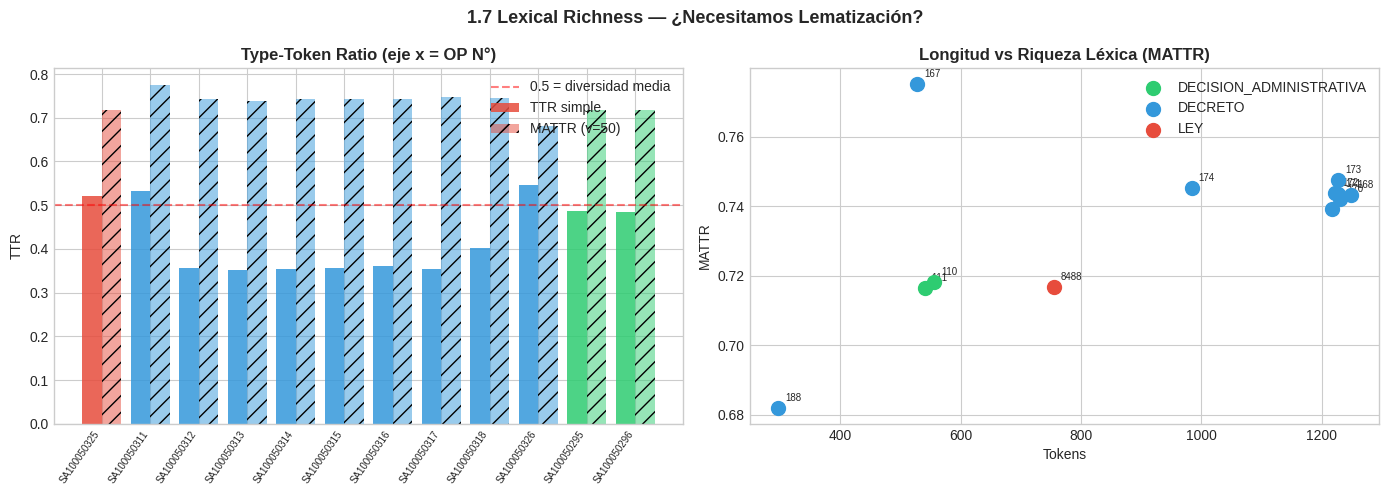

   OP N°: SA100050325      LEY_8488                 : TTR=0.521  → OK
   OP N°: SA100050311      DECRETO_167              : TTR=0.532  → OK
   OP N°: SA100050312      DECRETO_168              : TTR=0.357  → lematizar
   OP N°: SA100050313      DECRETO_169              : TTR=0.353  → lematizar
   OP N°: SA100050314      DECRETO_170              : TTR=0.354  → lematizar
   OP N°: SA100050315      DECRETO_171              : TTR=0.357  → lematizar
   OP N°: SA100050316      DECRETO_172              : TTR=0.362  → lematizar
   OP N°: SA100050317      DECRETO_173              : TTR=0.355  → lematizar
   OP N°: SA100050318      DECRETO_174              : TTR=0.402  → OK
   OP N°: SA100050326      DECRETO_188              : TTR=0.547  → OK
   OP N°: SA100050295      DECISION_ADMINISTRATIVA_110: TTR=0.488  → OK
   OP N°: SA100050296      DECISION_ADMINISTRATIVA_111: TTR=0.483  → OK


In [ ]:
def calcular_ttr(texto, ventana=None):
    tok = [t for t in word_tokenize(texto.lower(), language='spanish') if t.isalpha()]
    if not tok: return 0
    if ventana is None: return len(set(tok)) / len(tok)
    ttrs = [len(set(tok[i:i+ventana]))/ventana for i in range(len(tok)-ventana+1)]
    return np.mean(ttrs) if ttrs else 0

df['ttr_simple'] = df['texto'].apply(calcular_ttr)
df['ttr_mattr']  = df['texto'].apply(lambda x: calcular_ttr(x, 50))
bar_colors = [TIPO_COLORS.get(t,'#95a5a6') for t in df['tipo']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(df))

axes[0].bar(x-0.2, df['ttr_simple'], 0.4, color=bar_colors, alpha=0.85, label='TTR simple')
axes[0].bar(x+0.2, df['ttr_mattr'],  0.4, color=bar_colors, alpha=0.5,  hatch='//', label='MATTR (v=50)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    df['op_codigo'].str.replace('OP N°: ','',regex=False),
    rotation=55, ha='right', fontsize=7)
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='0.5 = diversidad media')
axes[0].set_title('Type-Token Ratio (eje x = OP N°)', fontweight='bold')
axes[0].set_ylabel('TTR'); axes[0].legend()

for tipo, grp in df.groupby('tipo'):
    axes[1].scatter(grp['num_tokens'], grp['ttr_mattr'],
                    label=tipo, color=TIPO_COLORS[tipo], s=100, zorder=5)
    for _, row in grp.iterrows():
        axes[1].annotate(row['numero'], (row['num_tokens'], row['ttr_mattr']),
                         xytext=(5,5), textcoords='offset points', fontsize=7)
axes[1].set_title('Longitud vs Riqueza Léxica (MATTR)', fontweight='bold')
axes[1].set_xlabel('Tokens'); axes[1].set_ylabel('MATTR'); axes[1].legend()

plt.suptitle('1.7 Lexical Richness — ¿Necesitamos Lematización?',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

for _, row in df.iterrows():
    rec = '→ lematizar' if row['ttr_simple'] < 0.40 else '→ OK'
    print(f'   {row["op_codigo"]:22s}  {row["id"]:25s}: TTR={row["ttr_simple"]:.3f}  {rec}')

### 1.8 Caracteres Especiales del PDF

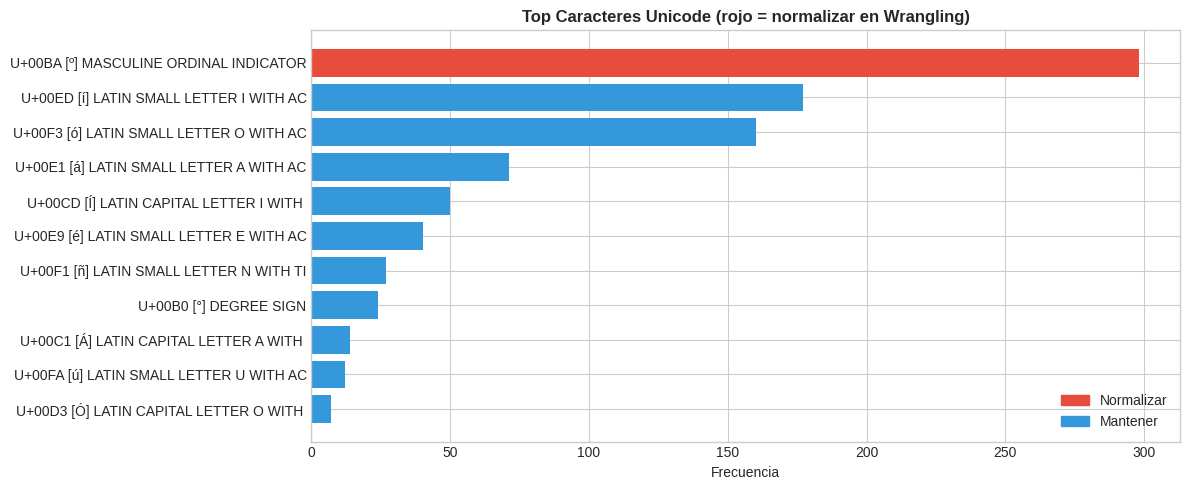

📌 Non-ASCII: 880 ocurrencias en 11 tipos únicos


In [ ]:
corpus_full = ' '.join(df['texto'])
chars_esp = {}
for c in corpus_full:
    if ord(c) > 127:
        k = f'U+{ord(c):04X} [{c}] {unicodedata.name(c,"UNK")[:28]}'
        chars_esp[k] = chars_esp.get(k, 0) + 1

NORMALIZAR = {'U+00BA','U+00AA','U+2013','U+2014'}
top_chars  = sorted(chars_esp.items(), key=lambda x: x[1], reverse=True)[:15]

fig, ax = plt.subplots(figsize=(12, 5))
lbls = [k[:50] for k,_ in top_chars]
vals = [v for _,v in top_chars]
clrs = ['#e74c3c' if any(n in k for n in NORMALIZAR) else '#3498db' for k in lbls]
ax.barh(lbls[::-1], vals[::-1], color=clrs[::-1])
ax.set_title('Top Caracteres Unicode (rojo = normalizar en Wrangling)', fontweight='bold')
ax.set_xlabel('Frecuencia')
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Normalizar'),
    mpatches.Patch(color='#3498db', label='Mantener')
])
plt.tight_layout(); plt.show()
print(f'📌 Non-ASCII: {sum(chars_esp.values())} ocurrencias en {len(chars_esp)} tipos únicos')

---
# 🔧 FASE 2: Wrangling — Limpieza y Normalización

### 2.1 Pipeline de Limpieza

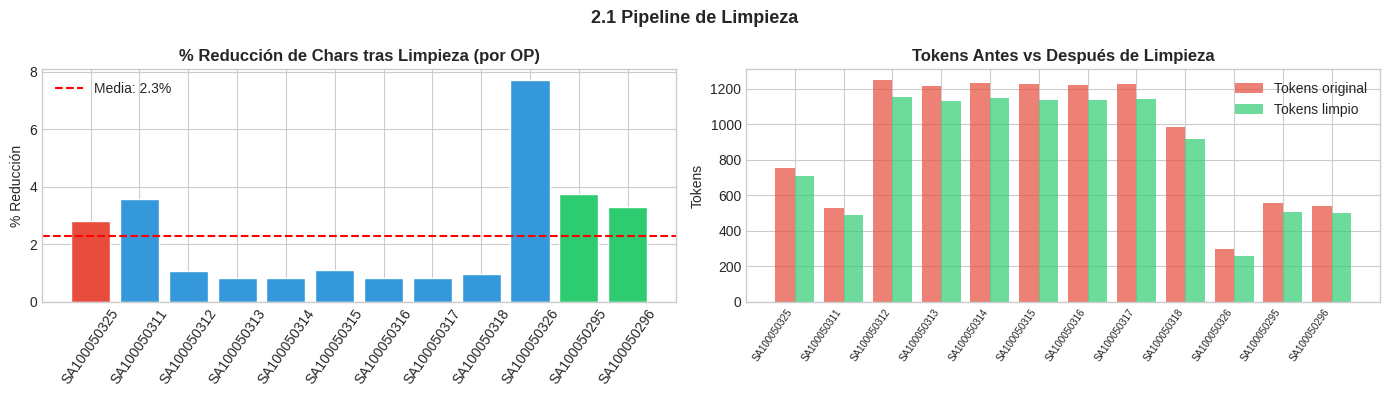

🧹 Ejemplo ANTES vs DESPUÉS (DECRETO_168):
ANTES:
'SALTA, 25 de Marzo de 2025\nDECRETO Nº 168\nMINISTERIO DE SEGURIDAD Y JUSTICIA\nExpediente Nº 0140044-100275/2024-0\nPág. N° 9\nVISTO el pedido de Retiro Voluntario presentado por el Suboficial Principal de la\nPolicía de la Provincia de Salta, Carlos Cristian Figueroa Rueda; y,\nCONSID'

DESPUÉS:
'SALTA, 25 de Marzo de 2025\nDECRETO No 168\nMINISTERIO DE SEGURIDAD Y JUSTICIA\nExpediente No 0140044-100275/2024-0\n\nVISTO el pedido de Retiro Voluntario presentado por el Suboficial Principal de la\nPolicía de la Provincia de Salta, Carlos Cristian Figueroa Rueda; y,\nCONSIDERANDO:\nQ'


In [ ]:
# Patrón OP reutilizado para limpiar el sufijo dentro del texto limpio
PATRON_OP_SUFIJO = re.compile(
    r'Fechas?\s+de\s+publicaci[oó]n:\s*[\d/]+\s*\n?'
    r'OP\s*N[°º]:\s*[A-Z]*\d{6,}',
    re.IGNORECASE
)

def limpiar_boletin(texto):
    """Elimina boilerplate: cabeceras, números de página, bloque OP-publicación."""
    texto = HEADER_RE.sub('', texto)                                    # cabecera repetida
    texto = re.sub(r'\bPág\.?\s*N[°º]?\s*°?\s*\d+\b', '', texto)      # nros de página
    texto = PATRON_OP_SUFIJO.sub('', texto)                             # bloque fecha-pub + OP
    return texto

def normalizar_unicode(texto):
    return unicodedata.normalize('NFC',
           texto.replace('º','o').replace('ª','a')
                .replace('\u2013','-').replace('\u2014',' - '))

def unificar_espacios(texto):
    """Repara \\n huérfanos del PDF (líneas partidas)."""
    texto = re.sub(r'\n{3,}', '\n\n', texto)
    texto = re.sub(r'([a-záéíóúñü,])\n([a-záéíóúñü])', r'\1 \2', texto)
    texto = re.sub(r'[ \t]+', ' ', texto)
    return texto.strip()

def normalizar_siglas(texto):
    for pat, rep in [
        (r'\bANSES\b', 'Administracion Nacional Seguridad Social'),
        (r'\bD\.N\.I\.\b', 'DNI'), (r'\bD\.N\.I\b', 'DNI'),
    ]:
        texto = re.sub(pat, rep, texto)
    return texto

def pipeline_limpieza(texto):
    return normalizar_siglas(
           unificar_espacios(
           normalizar_unicode(
           limpiar_boletin(texto))))

df['texto_limpio']    = df['texto'].apply(pipeline_limpieza)
df['chars_reduccion'] = (df['num_chars'] - df['texto_limpio'].apply(len)) / df['num_chars'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bar_colors = [TIPO_COLORS.get(t,'#95a5a6') for t in df['tipo']]

# Reducción por documento
axes[0].bar(df['op_codigo'].str.replace('OP N°: ','',regex=False),
            df['chars_reduccion'], color=bar_colors, edgecolor='white')
axes[0].axhline(df['chars_reduccion'].mean(), color='red', linestyle='--',
                label=f'Media: {df["chars_reduccion"].mean():.1f}%')
axes[0].set_title('% Reducción de Chars tras Limpieza (por OP)', fontweight='bold')
axes[0].set_ylabel('% Reducción'); axes[0].tick_params(axis='x', rotation=55); axes[0].legend()

# Tokens antes vs después
df['tokens_limpio'] = df['texto_limpio'].apply(lambda x: len(enc.encode(x)))
x = np.arange(len(df))
axes[1].bar(x-0.2, df['num_tokens'],    0.4, label='Tokens original', color='#e74c3c', alpha=0.7)
axes[1].bar(x+0.2, df['tokens_limpio'], 0.4, label='Tokens limpio',   color='#2ecc71', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    df['op_codigo'].str.replace('OP N°: ','',regex=False),
    rotation=55, ha='right', fontsize=7)
axes[1].set_title('Tokens Antes vs Después de Limpieza', fontweight='bold')
axes[1].set_ylabel('Tokens'); axes[1].legend()

plt.suptitle('2.1 Pipeline de Limpieza', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('🧹 Ejemplo ANTES vs DESPUÉS (DECRETO_168):')
ej = df[df['id']=='DECRETO_168'].iloc[0]
print('ANTES:');    print(repr(ej['texto'][:280]))
print('\nDESPUÉS:'); print(repr(ej['texto_limpio'][:280]))

### 2.2 Duplicados Semánticos y Enriquecimiento

In [ ]:
from langdetect import detect

def detectar_idioma(t):
    try: return detect(t)
    except: return 'unknown'

def simhash_doc(texto, k=3):
    palabras = texto.lower().split()
    h = 0
    for s in {' '.join(palabras[i:i+k]) for i in range(len(palabras)-k+1)}:
        h ^= int(hashlib.md5(s.encode()).hexdigest(), 16) % (2**32)
    return h

df['idioma']   = df['texto_limpio'].apply(detectar_idioma)
df['hash_md5'] = df['texto_limpio'].apply(lambda x: hashlib.md5(x.lower().strip().encode()).hexdigest()[:16])
df['simhash']  = df['texto_limpio'].apply(simhash_doc)

print('📌 Idioma y hash MD5 por documento:')
for _, row in df.iterrows():
    print(f'   {row["op_codigo"]:22s}  {row["id"]:25s}: lang={row["idioma"]}  md5={row["hash_md5"]}')

print('\n📌 Pares cuasi-idénticos (SimHash XOR + TF-IDF):')
for i in range(len(df)):
    for j in range(i+1, len(df)):
        sh  = 1 - bin(df.iloc[i]['simhash'] ^ df.iloc[j]['simhash']).count('1') / 32
        tfs = sim_matrix[i, j]
        if sh > 0.75 or tfs > 0.60:
            print(f'   {df.iloc[i]["op_codigo"]:22s} ↔ {df.iloc[j]["op_codigo"]:22s}  SimHash={sh:.2f}  TF-IDF={tfs:.2f}')

# Enriquecimiento: contexto global al inicio de cada chunk
df['texto_enriquecido'] = df.apply(
    lambda r: (
        f'[DOC: {r["tipo"]} No {r["numero"]} | OP: {r["op_codigo"]} | '
        f'FECHA: {r["fecha"]} | BOLETIN: Edicion 21.922 | '
        f'MINISTERIO: {r["ministerio"]}]\n\n' + r['texto_limpio']
    ), axis=1
)
print('\n✅ Enriquecimiento aplicado')

📌 Idioma y hash MD5 por documento:
   OP N°: SA100050325      LEY_8488                 : lang=es  md5=07f22ecac65aaac7
   OP N°: SA100050311      DECRETO_167              : lang=es  md5=80b77060622ce9dc
   OP N°: SA100050312      DECRETO_168              : lang=es  md5=355849e0e3b418e5
   OP N°: SA100050313      DECRETO_169              : lang=es  md5=31dd8b46717692f4
   OP N°: SA100050314      DECRETO_170              : lang=es  md5=2c4d8d2e385ae4f0
   OP N°: SA100050315      DECRETO_171              : lang=es  md5=647dc6cb7698c6fa
   OP N°: SA100050316      DECRETO_172              : lang=es  md5=b5f110b98be08c8e
   OP N°: SA100050317      DECRETO_173              : lang=es  md5=e62060bb23fc34cd
   OP N°: SA100050318      DECRETO_174              : lang=es  md5=a7a31937be62ea8b
   OP N°: SA100050326      DECRETO_188              : lang=es  md5=c1329c23717493d5
   OP N°: SA100050295      DECISION_ADMINISTRATIVA_110: lang=es  md5=592a39d504f5c27e
   OP N°: SA100050296      DECISION_ADM

---
# ✂️ FASE 3: Chunking & Metadata

### 3.1 Baseline Fixed-Size (muestra sus fallos)

In [ ]:
def chunk_fixed(texto, size=200):
    toks = enc.encode(texto)
    return [enc.decode(toks[i:i+size]) for i in range(0, len(toks), size)]

ej_texto   = df[df['id']=='DECRETO_168']['texto_limpio'].iloc[0]
chunks_fix = chunk_fixed(ej_texto, 200)
print('❌ Fixed-size — fallos evidentes:')
for i, c in enumerate(chunks_fix[:3]):
    print(f'\n  Chunk {i+1} ({len(enc.encode(c))} tok) | termina en punto: {c.rstrip().endswith((".",":",";"))}')
    print(f'  {repr(c[:160])}')

❌ Fixed-size — fallos evidentes:

  Chunk 1 (200 tok) | termina en punto: False
  'SALTA, 25 de Marzo de 2025\nDECRETO No 168\nMINISTERIO DE SEGURIDAD Y JUSTICIA\nExpediente No 0140044-100275/2024-0\n\nVISTO el pedido de Retiro Voluntario presentad'

  Chunk 2 (200 tok) | termina en punto: False
  ' por la cual corresponde conceder el beneficio invocado;\nQue la liquidación tendiente a la determinación del haber de retiro cuenta con el visado positivo de la'

  Chunk 3 (200 tok) | termina en punto: False
  'ucado, de conformidad con lo establecido en el artículo 2o inciso j) del Decreto No 515/2000 y los artículos 71 y 72 del Decreto No 1950/1977, modificados por e'


### 3.2 Recursive Character Splitting con Separadores Legales + Overlap 15%

In [ ]:
SEPARADORES_LEGALES = [
    r'ART[IÍ]CULO\s+\d+[°oº]\.-',    # Artículos — máxima prioridad
    r'CONSIDERANDO:',
    r'\n\n',
    r'(?<=[.;:])\s+(?=[A-ZÁÉÍÓ])',    # Fin oración + Mayúscula
    r'\n', r'\.', r' ',
]

def recursive_split(texto, chunk_tokens=250, overlap=38, sep_idx=0):
    if len(enc.encode(texto)) <= chunk_tokens:
        return [texto] if texto.strip() else []
    if sep_idx >= len(SEPARADORES_LEGALES):
        t = enc.encode(texto)
        return [enc.decode(t[:chunk_tokens]), enc.decode(t[chunk_tokens:])]

    partes = re.split(f'({SEPARADORES_LEGALES[sep_idx]})', texto)
    segmentos, actual = [], ''
    for p in partes:
        candidato = actual + p
        if len(enc.encode(candidato)) > chunk_tokens and actual:
            segmentos.append(actual.strip()); actual = p
        else:
            actual = candidato
    if actual.strip(): segmentos.append(actual.strip())

    resultado = []
    for seg in segmentos:
        resultado.extend(recursive_split(seg, chunk_tokens, overlap, sep_idx+1)
                         if len(enc.encode(seg)) > chunk_tokens
                         else ([seg] if seg.strip() else []))

    if overlap > 0 and len(resultado) > 1:
        con_ov = [resultado[0]]
        for i in range(1, len(resultado)):
            prev = enc.decode(enc.encode(resultado[i-1])[-overlap:])
            con_ov.append(prev + ' ' + resultado[i])
        return con_ov
    return resultado

chunks_rows = [
    {'doc_id': row['id'], 'op_codigo': row['op_codigo'], 'op_numero': row['op_numero'],
     'tipo_doc': row['tipo'], 'chunk_idx': i, 'texto': c,
     'num_tokens': len(enc.encode(c))}
    for _, row in df.iterrows()
    for i, c in enumerate(recursive_split(row['texto_limpio']))
    if len(enc.encode(c)) >= 30
]
df_chunks = pd.DataFrame(chunks_rows)

print(f'✅ {len(df_chunks)} chunks generados')
print(f'   Tokens: media={df_chunks["num_tokens"].mean():.0f}  '
      f'min={df_chunks["num_tokens"].min()}  max={df_chunks["num_tokens"].max()}')

✅ 59 chunks generados
   Tokens: media=244  min=76  max=400


### 3.3 Extracción Automática de Metadatos por Chunk

In [ ]:
def resumen_auto(texto, tipo):
    if 'retiro voluntario' in texto.lower():
        m = re.search(r'(?:Suboficial\s+(?:Principal|Mayor)|Sargento)[\w\s]+', texto)
        return f'Retiro: {m.group()[:35].strip()}' if m else 'Retiro voluntario policial'
    if 'afectación' in texto.lower():  return 'Afectación transitoria personal educación'
    if 'multa' in texto.lower():        return 'Sanciones — cursos no autorizados'
    if 'renuncia' in texto.lower():     return 'Aceptación de renuncia'
    if re.search(r'ART[IÍ]CULO\s+1', texto): return f'Disposición principal {tipo}'
    return f'{tipo.lower().replace("_"," ")}'

doc_lookup = {row['id']: row for _, row in df.iterrows()}

metadatos = []
for _, cr in df_chunks.iterrows():
    doc = doc_lookup[cr['doc_id']]
    t   = cr['texto']
    metadatos.append({
        # Identificadores
        'chunk_id':    f"{cr['doc_id']}_c{cr['chunk_idx']:02d}",
        'doc_id':      doc['id'],
        'op_codigo':   doc['op_codigo'],
        'op_numero':   doc['op_numero'],
        # Metadatos del documento
        'tipo':        doc['tipo'],
        'numero':      doc['numero'],
        'fecha':       doc['fecha'],
        'fecha_pub':   doc['fecha_pub'],
        'ministerio':  doc['ministerio'],
        'expediente':  doc['expediente'],
        # Métricas del chunk
        'num_tokens':  len(enc.encode(t)),
        # Flags semánticos
        'tiene_articulo':    bool(re.search(r'ART[IÍ]CULO\s+\d', t, re.I)),
        'tiene_persona':     bool(re.search(r'D\.?N\.?I', t)),
        'tiene_fecha':       bool(re.search(r'\d{1,2}/\d{1,2}/\d{4}', t)),
        'tiene_monto':       bool(re.search(r'\d[\d\.]+\s+unidades\s+tributarias', t, re.I)),
        'tiene_sancion':     bool(re.search(r'sanci[oó]n|multa|apercibimiento', t, re.I)),
        'tiene_retiro':      bool(re.search(r'retiro\s+voluntario', t, re.I)),
        'tiene_afectacion':  bool(re.search(r'afectaci[oó]n', t, re.I)),
        # Sección legal
        'seccion': (
            'CONSIDERANDO' if 'considerando' in t.lower() else
            'ARTICULO'     if re.search(r'ART[IÍ]CULO', t) else
            'VISTO'        if t.upper().startswith('VISTO') else
            'FIRMA'        if re.search(r'SÁENZ|SAENZ|Demitrópulos', t) else 'CONTENIDO'
        ),
        'resumen_auto': resumen_auto(t, doc['tipo']),
        'texto': t
    })

df_final = pd.DataFrame(metadatos)
print(df_final[['chunk_id','op_codigo','tipo','seccion','num_tokens',
                'tiene_retiro','tiene_sancion','resumen_auto']].to_string(index=False))

                       chunk_id          op_codigo                    tipo      seccion  num_tokens  tiene_retiro  tiene_sancion                                 resumen_auto
                   LEY_8488_c00 OP N°: SA100050325                     LEY    CONTENIDO         182         False           True                                          ley
                   LEY_8488_c01 OP N°: SA100050325                     LEY    CONTENIDO         400         False           True            Sanciones — cursos no autorizados
                   LEY_8488_c02 OP N°: SA100050325                     LEY    CONTENIDO         344         False          False                                          ley
                   LEY_8488_c03 OP N°: SA100050325                     LEY     ARTICULO         122         False          False                    Disposición principal LEY
                DECRETO_167_c00 OP N°: SA100050311                 DECRETO CONSIDERANDO         100         False          False  

### 3.4 Dashboard Final

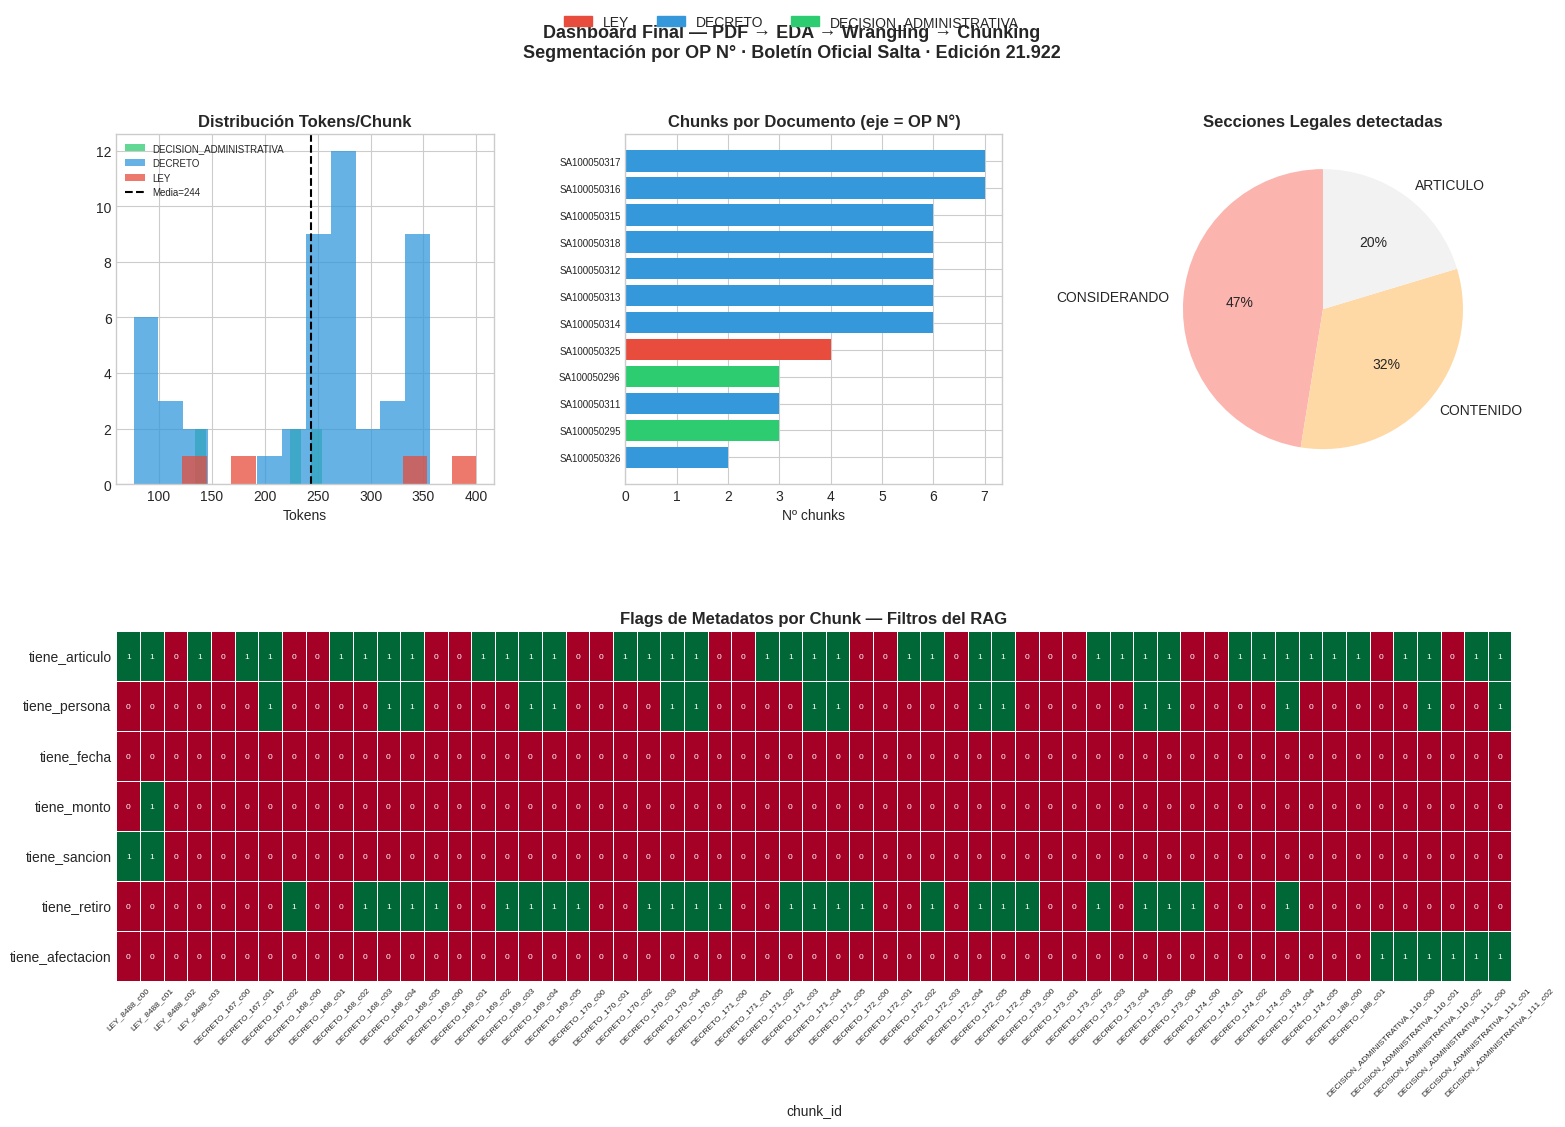

In [ ]:
fig = plt.figure(figsize=(18, 11))
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)

# Tokens por chunk
ax1 = fig.add_subplot(gs[0, 0])
for tipo, grp in df_final.groupby('tipo'):
    ax1.hist(grp['num_tokens'], bins=12, alpha=0.75, label=tipo, color=TIPO_COLORS.get(tipo,'#95a5a6'))
ax1.axvline(df_final['num_tokens'].mean(), color='black', linestyle='--',
            label=f'Media={df_final["num_tokens"].mean():.0f}')
ax1.set_title('Distribución Tokens/Chunk', fontweight='bold')
ax1.set_xlabel('Tokens'); ax1.legend(fontsize=7)

# Chunks por documento (eje y = OP)
ax2 = fig.add_subplot(gs[0, 1])
by_op = df_final.groupby('op_codigo').size().sort_values()
doc_tipo_by_op = dict(zip(df['op_codigo'], df['tipo']))
ax2.barh(
    [op.replace('OP N°: ','') for op in by_op.index],
    by_op.values,
    color=[TIPO_COLORS.get(doc_tipo_by_op.get(op,''), '#95a5a6') for op in by_op.index]
)
ax2.set_title('Chunks por Documento (eje = OP N°)', fontweight='bold')
ax2.set_xlabel('Nº chunks'); ax2.tick_params(axis='y', labelsize=7)

# Secciones
ax3 = fig.add_subplot(gs[0, 2])
secc = df_final['seccion'].value_counts()
ax3.pie(secc, labels=secc.index, autopct='%1.0f%%',
        colors=plt.cm.Pastel1(np.linspace(0, 1, len(secc))), startangle=90)
ax3.set_title('Secciones Legales detectadas', fontweight='bold')

# Heatmap de flags
ax4   = fig.add_subplot(gs[1, :])
flags = ['tiene_articulo','tiene_persona','tiene_fecha',
         'tiene_monto','tiene_sancion','tiene_retiro','tiene_afectacion']
pivot = df_final.set_index('chunk_id')[flags].astype(int)
sns.heatmap(pivot.T, annot=True, fmt='d', cmap='RdYlGn',
            ax=ax4, cbar=False, linewidths=0.4, annot_kws={'size': 6})
ax4.set_title('Flags de Metadatos por Chunk — Filtros del RAG', fontweight='bold')
ax4.tick_params(axis='x', rotation=45, labelsize=6)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in TIPO_COLORS.items()]
fig.legend(handles=legend_patches, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.0))
plt.suptitle(
    'Dashboard Final — PDF → EDA → Wrangling → Chunking\n'
    'Segmentación por OP N° · Boletín Oficial Salta · Edición 21.922',
    fontsize=13, fontweight='bold'
)
plt.show()

### 3.5 Exportar JSONL para Indexación RAG

In [ ]:
OUTPUT_COLS = [
    'chunk_id','doc_id','op_codigo','op_numero',
    'tipo','numero','fecha','fecha_pub','ministerio','expediente',
    'seccion','num_tokens','resumen_auto',
    'tiene_articulo','tiene_persona','tiene_fecha','tiene_monto',
    'tiene_sancion','tiene_retiro','tiene_afectacion','texto'
]

records = df_final[OUTPUT_COLS].to_dict(orient='records')

with open('boletin_salta_chunks.jsonl', 'w', encoding='utf-8') as f:
    for rec in records:
        f.write(json.dumps(rec, ensure_ascii=False) + '\n')

print('✅ boletin_salta_chunks.jsonl exportado')
print()
print('📌 Resumen del pipeline:')
print(f'   PDF procesado:   {PDF_PATH}')
print(f'   Páginas:         {len(pages_info)}')
print(f'   OPs detectados:  {len(df)} (= documentos)')
print(f'   Chunks finales:  {len(df_final)}')
print(f'   Tokens/chunk:    {df_final["num_tokens"].mean():.0f} (media)')
print()
print('🗂️  Nuevos filtros RAG disponibles gracias al OP N°:')
print('   filter(op_numero="SA100050312")     → documento exacto por OP')
print('   filter(tipo="DECRETO")              → todos los decretos')
print('   filter(tiene_retiro=True)           → retiros voluntarios policiales')
print('   filter(fecha>="2025-03-28")         → documentos recientes')
print('   filter(tiene_sancion=True)          → multas y sanciones')
print()
print('── Preview primer record ──')
print(json.dumps(records[0], ensure_ascii=False, indent=2)[:700])

✅ boletin_salta_chunks.jsonl exportado

📌 Resumen del pipeline:
   PDF procesado:   /content/02c_ejemplo_boletin.pdf
   Páginas:         13
   OPs detectados:  12 (= documentos)
   Chunks finales:  59
   Tokens/chunk:    244 (media)

🗂️  Nuevos filtros RAG disponibles gracias al OP N°:
   filter(op_numero="SA100050312")     → documento exacto por OP
   filter(tipo="DECRETO")              → todos los decretos
   filter(tiene_retiro=True)           → retiros voluntarios policiales
   filter(fecha>="2025-03-28")         → documentos recientes
   filter(tiene_sancion=True)          → multas y sanciones

── Preview primer record ──
{
  "chunk_id": "LEY_8488_c00",
  "doc_id": "LEY_8488",
  "op_codigo": "OP N°: SA100050325",
  "op_numero": "100050325",
  "tipo": "LEY",
  "numero": "8488",
  "fecha": "2025-03-27",
  "fecha_pub": "31/03/2025",
  "ministerio": "Gobernación de Salta",
  "expediente": "91-49969/2024",
  "seccion": "CONTENIDO",
  "num_tokens": 182,
  "resumen_auto": "ley",
  "tiene

---
## 🏁 Resumen del Pipeline

| Fase | Componente | Mejora respecto a versión anterior |
|------|-----------|------------------------------------|
| **0 — PDF** | pdfplumber | Sin cambio |
| **0 — PDF** | **Segmentador OP N°** | **Reemplaza regex de apertura** — más robusto, cero falsos positivos |
| **0 — PDF** | Parser metadatos | Agrega `op_codigo` y `op_numero` como campos indexables |
| **0 — PDF** | Mapa del corpus | Visualización posicional por OP |
| **1 — EDA** | Todos los gráficos | Eje x etiquetado con OP N° en lugar de id interno |
| **2 — Wrangling** | Limpieza | Elimina el bloque fecha-pub + OP del texto limpio |
| **2 — Wrangling** | Enriquecimiento | Agrega `OP: SAXXXXXX` al prefijo de contexto global |
| **3 — Chunking** | Metadatos | Agrega `op_codigo` y `op_numero` por chunk |
| **3 — Chunking** | Dashboard | Eje y del gráfico "chunks por doc" muestra OP N° |
| **3 — Chunking** | Exportación JSONL | Campo `op_codigo` disponible como filtro directo en Chroma/Pinecone |

### Por qué OP N° es mejor delimitador

```
ANTES (regex de apertura)          DESPUÉS (patrón OP)
─────────────────────────────────  ────────────────────────────────────
Busca inicio del documento         Busca FIN del documento
Falla si el tipo varía ("Ley" vs   Invariante: siempre "OP N°: SA1000..."
  "LEY" vs "Ley Nro.")
El decreto 184 se filtra a mano    No hay casos especiales
Un doc sin nombre reconocible      Todo doc tiene OP
  se pierde
El OP no queda como metadata       op_codigo y op_numero son filtros RAG
```

### Próximos pasos

```python
from sentence_transformers import SentenceTransformer
import chromadb

model      = SentenceTransformer('intfloat/multilingual-e5-large')
embeddings = model.encode([r['texto'] for r in records], show_progress_bar=True)

client     = chromadb.Client()
collection = client.create_collection('boletin_salta')
collection.add(
    embeddings = embeddings.tolist(),
    documents  = [r['texto'] for r in records],
    metadatas  = [{k: v for k, v in r.items() if k != 'texto'} for r in records],
    ids        = [r['chunk_id'] for r in records]
)

# Consultar por OP exacto
results = collection.query(
    query_texts = ['Retiro voluntario policía Salta'],
    where       = {'op_numero': {'$in': ['SA100050312','SA100050313']}},
    n_results   = 5
)
```